# 통계적 관점: 산점도와 추세선 (Scatter Plot)

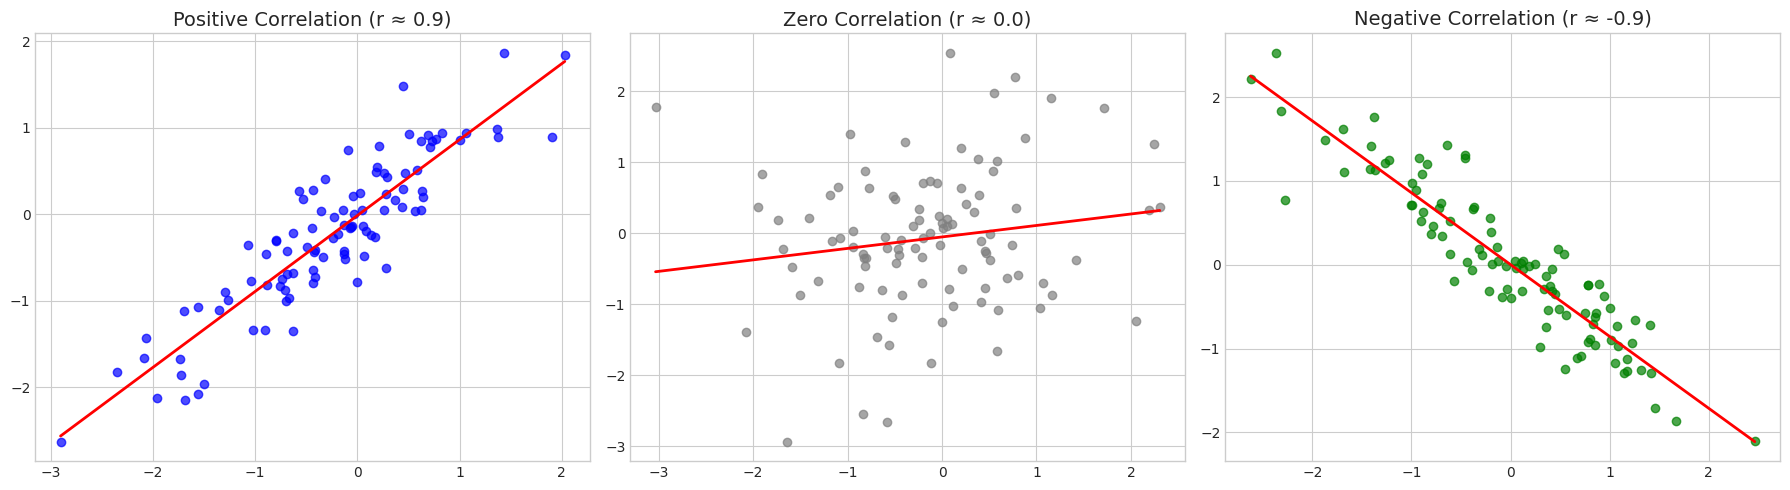

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 시각화 설정
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 데이터 생성 함수
def create_data(r, n=100):
    """지정된 상관계수 r을 갖는 2D 데이터를 생성합니다."""
    cov_matrix = [[1.0, r], [r, 1.0]] # 공분산 행렬
    data = np.random.multivariate_normal([0, 0], cov_matrix, n)
    return data[:, 0], data[:, 1]

# 1. 강한 양의 상관관계 (r = 0.9)
x1, y1 = create_data(0.9)
axes[0].scatter(x1, y1, alpha=0.7, color='blue')
axes[0].set_title("Positive Correlation (r ≈ 0.9)", fontsize=14)
axes[0].plot(np.unique(x1), np.poly1d(np.polyfit(x1, y1, 1))(np.unique(x1)), color='red', linewidth=2) # 추세선

# 2. 무상관 (r = 0)
x2, y2 = create_data(0.0)
axes[1].scatter(x2, y2, alpha=0.7, color='gray')
axes[1].set_title("Zero Correlation (r ≈ 0.0)", fontsize=14)
axes[1].plot(np.unique(x2), np.poly1d(np.polyfit(x2, y2, 1))(np.unique(x2)), color='red', linewidth=2)

# 3. 강한 음의 상관관계 (r = -0.9)
x3, y3 = create_data(-0.9)
axes[2].scatter(x3, y3, alpha=0.7, color='green')
axes[2].set_title("Negative Correlation (r ≈ -0.9)", fontsize=14)
axes[2].plot(np.unique(x3), np.poly1d(np.polyfit(x3, y3, 1))(np.unique(x3)), color='red', linewidth=2)

plt.tight_layout()
plt.show()

# 기하학적 관점

- 파란색 화살표(데이터 A)에서 초록색 화살표(데이터 B)로 빛을 비췄을 때 생기는 붉은색 화살표가 바로 '투영(그림자)'입니다. 두 벡터 사이의 각도가 좁을수록 코사인 값(상관계수)이 1에 가까워지는 것을 눈으로 확인할 수 있습니다.

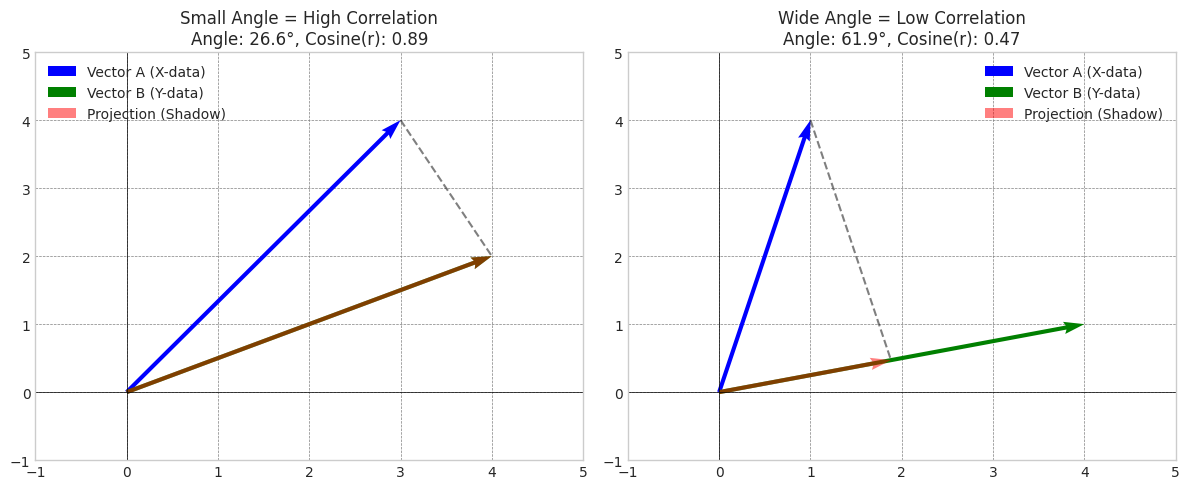

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_vector_projection(v1, v2, ax, title):
    # 원점
    origin = np.array([0, 0])
    
    # 벡터 그리기
    ax.quiver(*origin, *v1, angles='xy', scale_units='xy', scale=1, color='blue', label='Vector A (X-data)')
    ax.quiver(*origin, *v2, angles='xy', scale_units='xy', scale=1, color='green', label='Vector B (Y-data)')
    
    # 벡터 A를 벡터 B에 투영(Projection) - 그림자 계산
    projection_length = np.dot(v1, v2) / np.linalg.norm(v2)
    projection_vector = (projection_length / np.linalg.norm(v2)) * v2
    
    # 투영된 벡터(그림자)와 수직선 그리기
    ax.quiver(*origin, *projection_vector, angles='xy', scale_units='xy', scale=1, color='red', alpha=0.5, label='Projection (Shadow)')
    ax.plot([v1[0], projection_vector[0]], [v1[1], projection_vector[1]], 'k--', alpha=0.5)
    
    # 각도 계산 (코사인 유사도 = 피어슨 상관계수)
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    theta = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
    
    ax.set_xlim(-1, 5)
    ax.set_ylim(-1, 5)
    ax.axhline(0, color='black',linewidth=0.5)
    ax.axvline(0, color='black',linewidth=0.5)
    ax.grid(color='gray', linestyle='--', linewidth=0.5)
    ax.set_title(f"{title}\nAngle: {theta:.1f}°, Cosine(r): {cos_theta:.2f}")
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 각도가 좁을 때 (양의 상관관계)
v_A1 = np.array([3, 4])
v_B1 = np.array([4, 2])
plot_vector_projection(v_A1, v_B1, axes[0], "Small Angle = High Correlation")

# 2. 직각에 가까울 때 (무상관에 가까움)
v_A2 = np.array([1, 4])
v_B2 = np.array([4, 1])
plot_vector_projection(v_A2, v_B2, axes[1], "Wide Angle = Low Correlation")

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 실무와 유사한 가상의 데이터셋 생성 (예: 집값 예측 데이터)
np.random.seed(0)
size = 200
house_size = np.random.normal(100, 20, size)
rooms = house_size * 0.05 + np.random.normal(0, 1, size) # 방 개수는 집 크기와 양의 상관관계
distance_to_subway = np.random.normal(10, 5, size)
# 집값: 크기가 클수록(+), 지하철이 멀수록(-)
price = house_size * 500 - distance_to_subway * 200 + np.random.normal(0, 5000, size)

df = pd.DataFrame({
    'House_Size': house_size,
    'Num_Rooms': rooms,
    'Dist_to_Subway': distance_to_subway,
    'Price(Target)': price
})

# 피어슨 상관계수 행렬 계산
corr_matrix = df.corr(method='pearson')

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,      # 상자 안에 실제 상관계수 값 표시
            fmt=".2f",       # 소수점 2자리까지
            cmap='coolwarm', # 색상 테마 (파란색: 음수, 붉은색: 양수)
            vmin=-1, vmax=1, # 색상 척도의 최소/최대값
            center=0,
            linewidths=0.5)

plt.title("Feature Correlation Heatmap for AI Model", fontsize=16)
plt.show()

ModuleNotFoundError: No module named 'seaborn'